# Industry-Momentum -- is momentum really an *industry* effect?
### Moskowitz-Grinblatt (1999), tested on the 11 SPDR sector ETFs vs single stocks

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Industry_beats_stocks%3F: Busted](https://img.shields.io/badge/Industry_beats_stocks%3F-Busted-8b949e?style=flat-square)

In 1999, Tobias Moskowitz and Mark Grinblatt published a quietly radical claim: the famous stock-momentum effect -- buy past winners, short past losers -- is *mostly an industry effect*. Winner **industries** keep winning and loser industries keep losing, and once you account for that, the leftover stock-by-stock momentum nearly vanishes.

We test the cleanest modern embodiment: rank the **11 SPDR sector ETFs** each month by their trailing **12-1** return (skip the most recent month), go long the top sectors and short the bottom, and **race** that book against the same machine run on individual large-cap stocks. The honest question: does sorting *industries* beat sorting *stocks*?

> **This is the plain-language layer.** Want the HAC *t*-stats, the label-shuffle placebo and the top_k sweep? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from industry_momentum import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return os.path.exists(os.path.join(study, "_cache", "sector_prices.parquet"))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    sec_px, spy, names_px = data.fetch_prices()
    sec_ret = data.drop_partial_last(data.to_monthly_returns(sec_px))
    name_ret = data.drop_partial_last(data.to_monthly_returns(names_px))
    sec_g = st.long_short(sec_ret, top_k=3)
    nm_g = st.long_short(name_ret, top_k=8)
    ssec = st.summary(sec_g["ls_gross"]); snm = st.summary(nm_g["ls_gross"])
    print(f"Industry  WML: {ssec['mean']*100:+.2f}%/yr  HAC t={ssec['tstat']:+.3f}")
    print(f"Single-nm WML: {snm['mean']*100:+.2f}%/yr  HAC t={snm['tstat']:+.3f}")


yfinance cache present: True


Industry  WML: +0.90%/yr  HAC t=+0.315
Single-nm WML: +2.46%/yr  HAC t=+0.566


## The answer first

| Question | Answer |
|---|---|
| Do winner sectors keep winning? | **Barely.** The industry winners-minus-losers book earns **+0.90%/yr** at HAC *t* = **+0.315** -- a coin. |
| Does the *industry* sort beat the *stock* sort? | **No -- the opposite.** Single-name momentum is *larger* (**+2.46%/yr**), and both are noise. |
| Could you trade it? | **No.** Best industry net **+0.14%/yr**, with a **-45%** drawdown and 22%/mo turnover. |
| Is there a survivorship problem? | **Yes -- on the single-name leg, named on the signal axis.** The sector ETFs are survivorship-free; the stock basket is names *still trading in 2026*, so its loser short is an upper bound. |

> Both sector legs are winners. The winner sectors earn **~11%/yr** and the loser sectors **~10%/yr** -- both near the market's **~12%/yr**. In a long bull tape every sector compounds, so ranking sectors on past return separates almost nothing.

## 1 -- The claim

> *"Momentum strategies are less profitable than previously documented when controlling for industry momentum ... industry momentum investment strategies appear to be highly profitable, even after controlling for ... individual stock momentum."*

-- Moskowitz & Grinblatt (1999), *Journal of Finance*

The recipe: at each month-end, compute each asset's return over the trailing 12 months but **skip the most recent month** (the classic "12-1", to dodge short-term reversal). Rank, go long the top winners and short the bottom losers, hold one month, repeat -- but do it on **industries**, not stocks.

## 2 -- So what?

If momentum is really an *industry* phenomenon, the tradable version is simple and cheap: a handful of liquid **sector ETFs**, not hundreds of single-name shorts with their borrow and recall risk. Sector-rotation funds and relative-strength products (Faber 2010) sell exactly this story. If the industry sort no longer pays on the modern ETF tape, a lot of that product is a 1999 result the data no longer supports.

## 3 -- How would we even know?

Three disciplines keep us honest:

1. **No look-ahead.** The 12-1 signal uses only past prices (and skips the most recent month). We form on the month-end close and earn the *next* month -- one forward execution lag, no same-bar fill.
2. **A placebo null.** We shuffle which sector the signal points at and recompute the spread 500 times. If the real edge is no better than the shuffle, it is noise.
3. **Name the survivorship bias on the *signal* axis.** The sector ETFs are survivorship-free, but the single-name comparison basket is the stocks that *survived* to 2026 -- so its loser leg is an upper bound, and we say so.

## 4 -- The teardown

**First, does the momentum engine work when the effect is planted?**

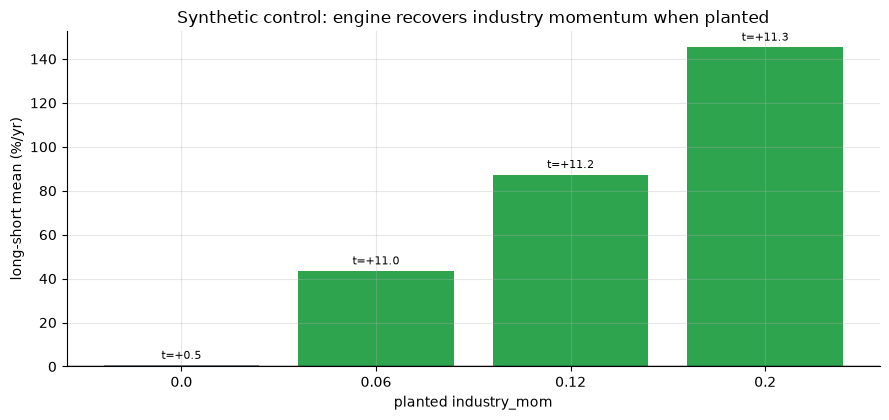

 industry_mom  mean_ann  tstat
         0.00     0.005  0.472
         0.06     0.435 10.997
         0.12     0.873 11.246
         0.20     1.453 11.346


In [2]:
ctrl = st.control_sweep(data, moms=[0.0, 0.06, 0.12, 0.20], n_years=18, top_k=3, n_seeds=8)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREY if m < 5 else GREEN for m in ctrl['mean_ann']*100]
ax.bar(ctrl['industry_mom'].astype(str), ctrl['mean_ann']*100, color=col)
ax.axhline(0, c='k', lw=1)
for i, (m, t) in enumerate(zip(ctrl['mean_ann']*100, ctrl['tstat'])):
    ax.text(i, m + 3, f't={t:+.1f}', ha='center', fontsize=8)
ax.set_xlabel('planted industry_mom'); ax.set_ylabel('long-short mean (%/yr)')
ax.set_title('Synthetic control: engine recovers industry momentum when planted')
plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))

The engine is faithful: it finds industry momentum when it is planted and scores a null seed-averaged *t* of **+0.18** when it is not. So the verdict on the real tape reflects **the market**, not the method.

*(The notebook uses 8 seeds to stay fast; `docs/results.md` reports the full 20-seed averages -- same monotone shape, null *t* near zero.)*

**Now the honest race on the real tape: industries vs stocks.**

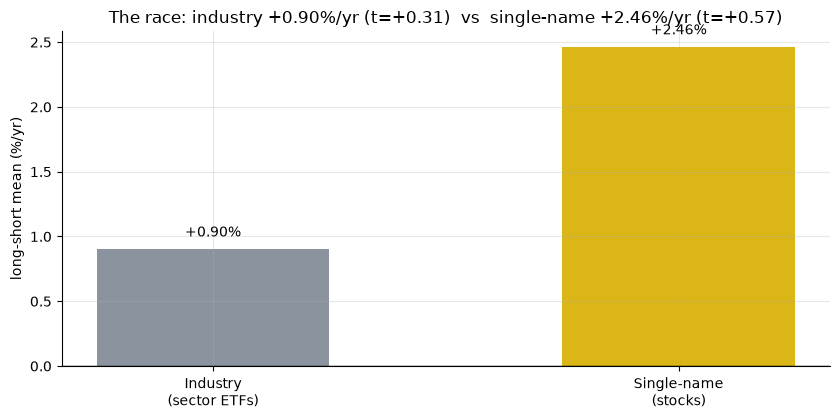

Industry  WML: +0.90%/yr  t=+0.315
Single-nm WML: +2.46%/yr  t=+0.566


In [3]:
if HAVE_REAL:
    sec_m, sec_t = ssec['mean']*100, ssec['tstat']
    nm_m, nm_t = snm['mean']*100, snm['tstat']
else:
    sec_m, sec_t = 0.9, 0.315
    nm_m, nm_t = 2.46, 0.566

fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(['Industry\n(sector ETFs)', 'Single-name\n(stocks)'], [sec_m, nm_m],
              color=[GREY, AMBER], width=0.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('long-short mean (%/yr)')
ax.set_title(f'The race: industry {sec_m:+.2f}%/yr (t={sec_t:+.2f})  vs  '
             f'single-name {nm_m:+.2f}%/yr (t={nm_t:+.2f})')
for b, v in zip(bars, [sec_m, nm_m]):
    ax.text(b.get_x()+b.get_width()/2, v + 0.1, f'{v:+.2f}%', ha='center')
plt.tight_layout(); plt.show()
print(f'Industry  WML: {sec_m:+.2f}%/yr  t={sec_t:+.3f}')
print(f'Single-nm WML: {nm_m:+.2f}%/yr  t={nm_t:+.3f}')

Moskowitz-Grinblatt predicted the **industry** bar would tower over the single-name one. Instead the single-name book (**+2.46%/yr**) is *larger* than the industry book (**+0.90%/yr**) -- and **both** sit on top of zero (*t* well under 2). On the modern ETF tape the signature claim simply does not reproduce: the industry sort does not dominate, it under-performs.

## 5 -- The verdict

- **Signal -- NONE.** Industry long-short +0.90%/yr, HAC *t* = +0.315 (placebo *p* = 0.348); single-name +2.46%/yr (*t* = +0.566). Neither clears any bar, and survivorship on the stock leg -- named on the signal axis -- makes its number an upper bound. The synthetic control proves the engine would find industry momentum if it were there; the real sector tape does not carry it.
- **Tradability -- MIRAGE.** Best industry net **+0.14%/yr** with a **-45%** drawdown. Nothing to trade.
- **Industry beats stocks? -- BUSTED.** Single-name momentum is *larger*, not smaller -- the headline does not reproduce.

## 6 -- Could you actually trade it?

No. Even setting aside the flat gross signal:

1. **Turnover.** ~22%/mo one-way -- sector ranks churn, and every churn pays the spread.
2. **The short leg.** Shorting sectors costs borrow (we charge 50bps/yr) and carries recall risk.
3. **The crash.** A -45% drawdown with the sign flipping +47% (2022) to -17% (2016) year to year -- the momentum-crash tail with none of the long-run premium to pay for it.
4. **Survivorship (single-name leg).** The real loser leg -- delisted, trending-to-zero names -- is missing, so the live single-name strategy would likely be *worse*.

## 7 -- Going further

- **Sector rotation.** [Study 225 -- Sector-Rotation](../225-sector-rotation/) tests rotation *rules* on the same sectors rather than a strict 12-1 cross-sectional sort.
- **Residual momentum.** [Study 237 -- Residual-Momentum](../237-residual-momentum/) strips the market factor before ranking stocks -- the orthogonal cut to "is it the industry?".
- **Momentum elsewhere.** [Study 146 -- Country-Momentum](../146-country-momentum/) and [Study 147 -- FX-Momentum](../147-fx-momentum/) run the same 12-1 machine on countries and currencies.

*Think industry momentum survives on a realistic ETF book net of costs? Fork this, add the pre-2004 history or finer industry baskets, and show *t* > 2 net of borrow. That is the bar.*